#### Instructions
###### Follow the instructions given in comments prefixed with ## and write your code below that.
###### Also fill the partial code in given blanks. 
###### Don't make any changes to the rest part of the codes

### Answer the questions given at the end of this notebook within your report.


### You would need to submit your GitHub repository link. Refer to the Section 6: Final Submission on the PDF document for the details.


In [2]:
!pip install numpy pandas scikit-learn wandb

In [3]:
import wandb
from kaggle_secrets import UserSecretsClient
user_secrets = UserSecretsClient()
secret_value_0 = user_secrets.get_secret("WANDB_API")

wandb.login(key=secret_value_0)

wandb: Using wandb-core as the SDK backend.  Please refer to https://wandb.me/wandb-core for more information.
wandb: Currently logged in as: tishabhavsar (tishabhavsar-plaksha-university). Use `wandb login --relogin` to force relogin
wandb: WARNING If you're specifying your api key in code, ensure this code is not shared publicly.
wandb: WARNING Consider setting the WANDB_API_KEY environment variable, or running `wandb login` from the command line.
wandb: Appending key for api.wandb.ai to your netrc file: /root/.netrc


True

In [4]:
## import cv2
## import numpy
## import matplotlib pyplotwandb.init(project='distance_classification_project')
## import KMeans cluster from sklearn
## import distance from scipy.spatial

import cv2
import numpy as np
import matplotlib.pyplot as plt 
from sklearn.cluster import KMeans
from scipy.spatial import distance
from matplotlib.offsetbox import OffsetImage, AnnotationBbox

In [5]:
wandb.init(project='distance_classification_project')

Text(0.5, 1.0, 'Total number of face detected are #')

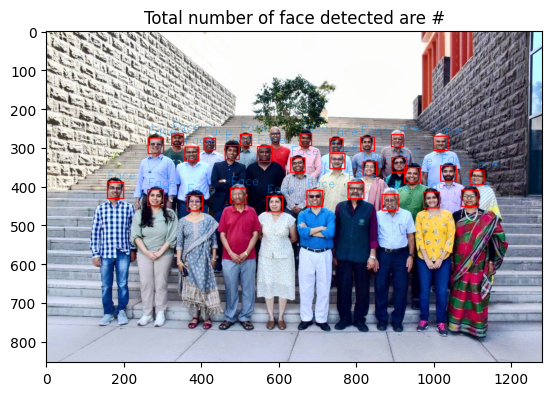

In [6]:
## Reading the image plaksha_Faculty.jpg
image = cv2.imread('/kaggle/input/mlprlab5/Plaksha_Faculty.jpg')
  
## Convert the image to grayscale
gray_img = cv2.cvtColor(image, cv2.COLOR_BGR2GRAY)
  
# Loading the required haar-cascade xml classifier file
face_cascade = cv2.CascadeClassifier('/kaggle/input/mlprlab5/face_cascade.xml')
  
# Applying the face detection method on the grayscale image. 
## Change the parameters for better detection of faces in your case.
faces_rect = face_cascade.detectMultiScale(gray_img, 1.05, 4, minSize=(25,25), maxSize=(50,50))
 
# Define the text and font parameters
text = "Face" ## The text you want to write
font = cv2.FONT_HERSHEY_SIMPLEX  ## Font type
font_scale = 1  ## Font scale factor
font_color = (250,150,10)  ## Text color in BGR format (here, it's red)
font_thickness = 1  ## Thickness of the text



# Iterating through rectangles of detected faces
for (x, y, w, h) in faces_rect:
    cv2.rectangle(image, (x, y), (x+w, y+h), (0, 0, 255), 2)
    # Use cv2.putText to add the text to the image, Use text, font, font_scale, font_color, font_thickness here
    cv2.putText(image, text, (x, y - 8),font, font_scale, font_color, font_thickness)
    
## Display the image and window title should be "Total number of face detected are #" 
image_rgb = cv2.cvtColor(image, cv2.COLOR_BGR2RGB)
plt.imshow(image_rgb)
plt.title("Total number of face detected are #")


/usr/local/lib/python3.10/dist-packages/sklearn/cluster/_kmeans.py:870: FutureWarning: The default value of `n_init` will change from 10 to 'auto' in 1.4. Set the value of `n_init` explicitly to suppress the warning
  warnings.warn(


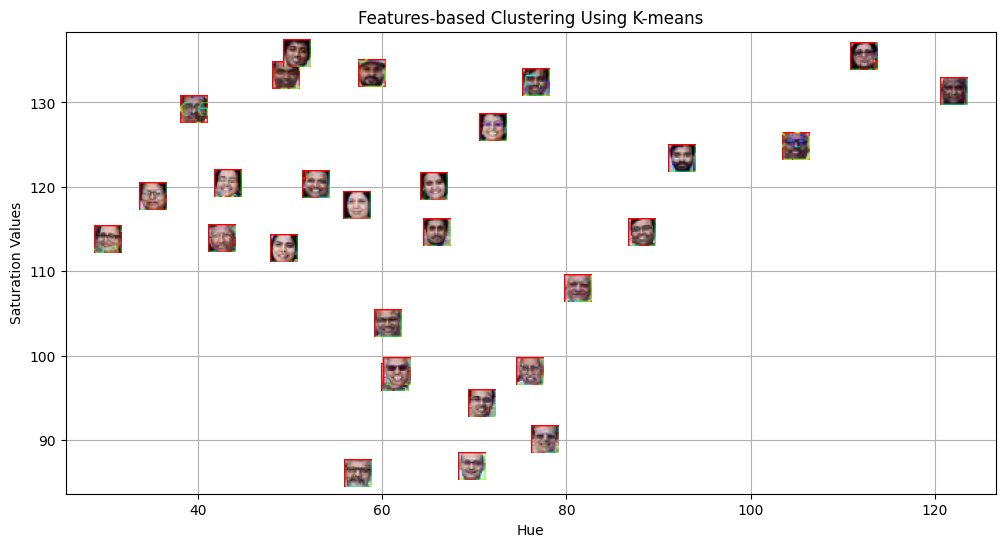

In [7]:
from matplotlib.offsetbox import OffsetImage, AnnotationBbox
# Extract face region features (Hue and Saturation)
img_hsv = cv2.cvtColor(image,cv2.COLOR_BGR2HSV) ## call the img and convert it from BGR to HSV and store in img_hsv
hue_saturation = []
face_images = []  # To store detected face images

for (x, y, w, h) in faces_rect:
    face = img_hsv[y:y + h, x:x + w]
    hue = np.mean(face[:, :, 0])
    saturation = np.mean(face[:, :, 1])
    hue_saturation.append((hue, saturation))
    face_images.append(face)

hue_saturation = np.array(hue_saturation)

## Perform k-Means clustering on hue_saturation and store in kmeans
kmeans = KMeans(n_clusters=2).fit(hue_saturation)
centroids = kmeans.cluster_centers_
labels = kmeans.labels_

# Create a figure and axis
fig, ax = plt.subplots(figsize=(12, 6))

# Plot the clustered faces with custom markers
for i, (x,y,w,h ) in enumerate(faces_rect):
    im = OffsetImage(cv2.cvtColor(cv2.resize(face_images[i], (20, 20)), cv2.COLOR_HSV2RGB))
    ab = AnnotationBbox(im, (hue_saturation[i, 0], hue_saturation[i, 1]), frameon=False, pad=0)
    ax.add_artist(ab)
    plt.plot(hue_saturation[i, 0], hue_saturation[i, 1])

plt.xlabel("Hue")
plt.ylabel("Saturation Values")
plt.title("Features-based Clustering Using K-means")
plt.grid(True)

# Logging graph to WandB
wandb.log({"Features-based Clustering Using Kmeans Graph": wandb.Image(plt)})
plt.show()


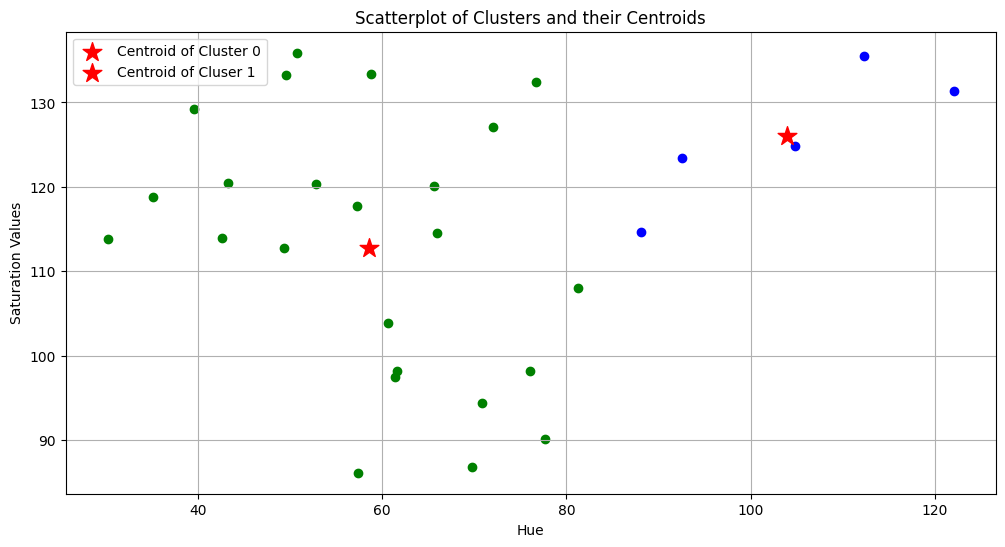

In [8]:
# Create an empty list to store legend labels
legend_labels = []

# Create lists to store points for each cluster
cluster_0_points = []
cluster_1_points = []

# Your code for scatter plot goes here
fig, ax = plt.subplots(figsize=(12, 6))
for i, (x, y, w, h) in enumerate(faces_rect):
    if kmeans.labels_[i] == 0:
        cluster_0_points.append((hue_saturation[i, 0], hue_saturation[i, 1]))
    else:
        cluster_1_points.append((hue_saturation[i, 0], hue_saturation[i, 1]))


cluster_0_points = np.array(cluster_0_points)
# Plot points for cluster 0 in green
plt.scatter(cluster_0_points[:, 0], cluster_0_points[:, 1], color = "g")

cluster_1_points = np.array(cluster_1_points)
# Plot points for cluster 1 in blue
plt.scatter(cluster_1_points[:, 0], cluster_1_points[:, 1], color = "b")

# Calculate and plot centroids
centroid_0 = np.mean(cluster_0_points, axis=0)
centroid_1 = np.mean(cluster_1_points, axis=0)

# Plot both the centroid for cluster 0 and cluster 1 
plt.scatter(centroid_0[0],centroid_0[1], color = 'r', s = 200, marker = '*', label = 'Centroid of Cluster 0')
plt.scatter(centroid_1[0], centroid_1[1], color = 'r', s = 200, marker = '*', label = 'Centroid of Cluser 1')
plt.xlabel("Hue")
plt.ylabel("Saturation Values")
plt.title("Scatterplot of Clusters and their Centroids")
plt.grid(True)
plt.legend()
# Logging graph to WandB
wandb.log({"Scatterplot of Clusters and their Centroids Graph": wandb.Image(plt)})
plt.show()

Text(0.5, 1.0, 'Template Image Picture')

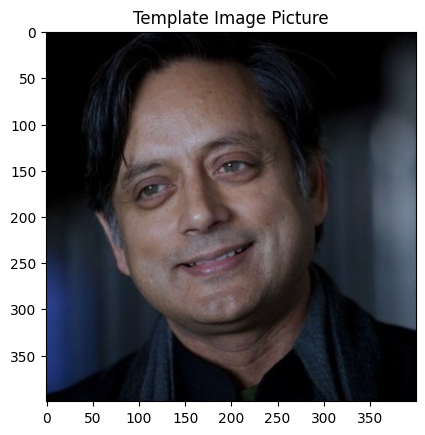

In [9]:
## Read the class of the template image 'Dr_Shashi_Tharoor.jpg' using cv2 and store it in template_img
template_img = cv2.imread('/kaggle/input/mlprlab5/Dr_Shashi_Tharoor.jpg')

#Converting image to grayscale
gray_img = cv2.cvtColor(template_img, cv2.COLOR_BGR2GRAY)
  
# Detect face  in the template image after converting it to gray and store it in template_faces
template_faces = face_cascade.detectMultiScale(gray_img, 1.1, 1, minSize=(10,10), maxSize=(100,100))
# Draw rectangles around the detected faces
for (x, y, w, h) in template_faces:
    cv2.rectangle(template_img, (x, y), (x + w, y + h), (255, 255, 255), 3)
template_image_rgb = cv2.cvtColor(template_img, cv2.COLOR_BGR2RGB)
plt.imshow(template_image_rgb)
plt.title("Template Image Picture")

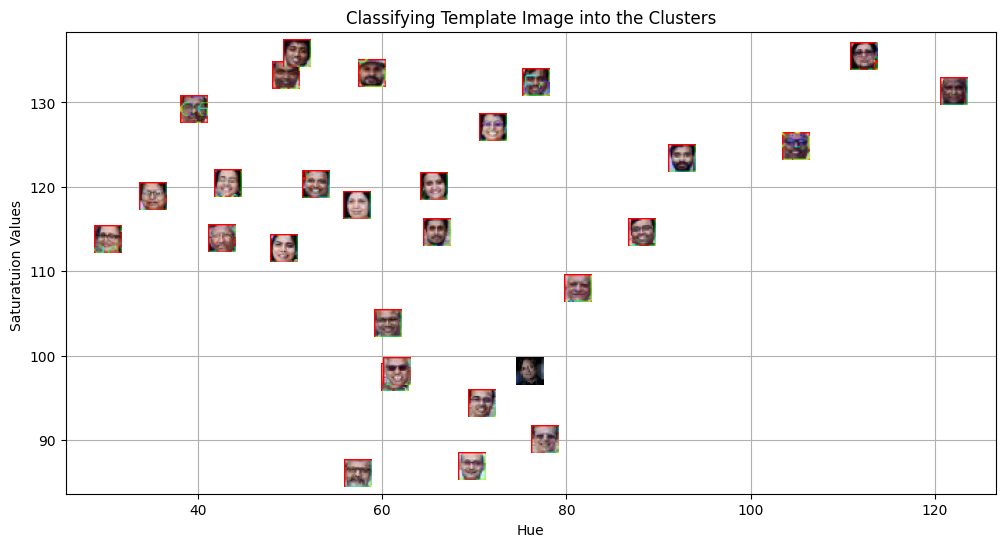

In [10]:
# Convert the template image to HSV color space and store it in template_hsv
template_hsv = cv2.cvtColor(image,cv2.COLOR_BGR2HSV)

# Extract hue and saturation features from the template image as we did it for detected faces.

template_face = template_hsv[y:y + h, x:x + w]
template_hue = np.mean(template_face[:, :, 0])
template_saturation = np.mean(template_face[:, :, 1])


# Predict the cluster label for the template image and store it in template_label
template_label = kmeans.predict(np.array([[template_hue, template_saturation]]))[0]

# Create a figure and axis for visualization
fig, ax = plt.subplots(figsize=(12, 6))

# Plot the clustered faces with custom markers (similar to previous code)
for i, (x, y, w, h) in enumerate(faces_rect):
    color = 'red' if kmeans.labels_[i] == 0 else 'blue'
    im = OffsetImage(cv2.cvtColor(cv2.resize(face_images[i], (20, 20)), cv2.COLOR_HSV2RGB))
    ab = AnnotationBbox(im, (hue_saturation[i, 0], hue_saturation[i, 1]), frameon=False, pad=0)
    ax.add_artist(ab)
    plt.plot(hue_saturation[i, 0], hue_saturation[i, 1], 'o', markersize=5, color=color)

# Plot the template image in the respective cluster
if template_label == 0:
    color = 'red'
else:
    color = 'blue'
im = OffsetImage(cv2.cvtColor(cv2.resize(template_img, (20, 20)), cv2.COLOR_BGR2RGB))
ab = AnnotationBbox(im, (template_hue, template_saturation), frameon=False, pad=0)
ax.add_artist(ab)

plt.xlabel("Hue")
plt.ylabel("Saturatuion Values ")
plt.title("Classifying Template Image into the Clusters")
plt.grid(True)

# Logging graph to WandB
wandb.log({"Classifying Template Image into the Clusters Graph": wandb.Image(plt)})
plt.show()

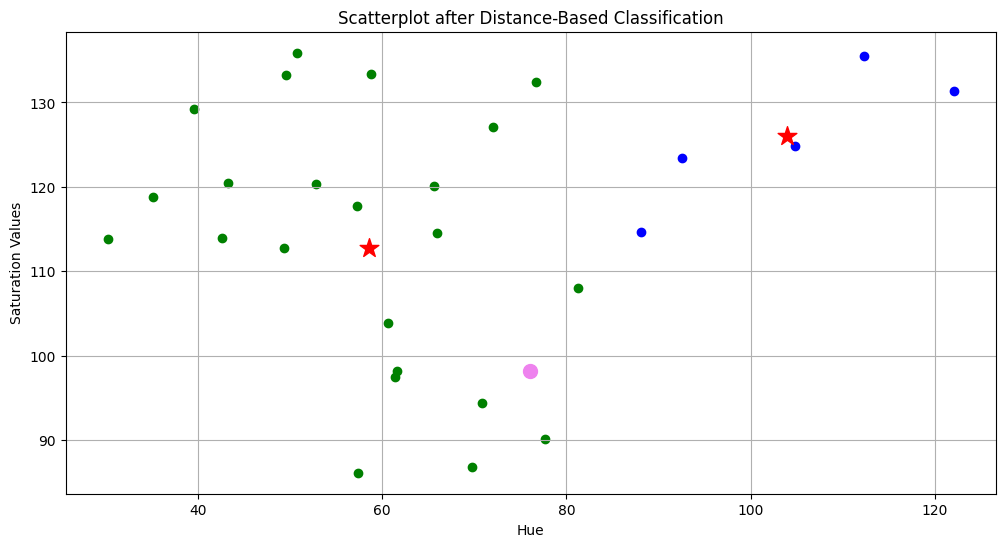

In [11]:
# Create an empty list to store legend labels
legend_labels = []

# Create lists to store points for each cluster
cluster_0_points = []
cluster_1_points = []

# Your code for scatter plot goes here
fig, ax = plt.subplots(figsize=(12, 6))
for i, (x, y, w, h) in enumerate(faces_rect):
    if kmeans.labels_[i] == 0:
        cluster_0_points.append((hue_saturation[i, 0], hue_saturation[i, 1]))
    else:
        cluster_1_points.append((hue_saturation[i, 0], hue_saturation[i, 1]))

# Plot points for cluster 0 in green
cluster_0_points = np.array(cluster_0_points)
plt.scatter(cluster_0_points[:, 0], cluster_0_points[:, 1], color = "g")

# Plot points for cluster 1 in blue
cluster_1_points = np.array(cluster_1_points)
plt.scatter(cluster_1_points[:, 0], cluster_1_points[:, 1], color = "b")

# Calculate and plot centroids for both the clusters
centroid_0 = np.mean(cluster_0_points, axis=0)
centroid_1 = np.mean(cluster_1_points, axis=0)
plt.scatter(centroid_0[0],centroid_0[1], color = 'r', marker = '*', s=200, label = 'Centroid 1')
plt.scatter(centroid_1[0], centroid_1[1], color = 'r', marker = '*', s=200, label = 'Centroid 2')
plt.plot(template_hue, template_saturation, marker='o', c= 'violet',markersize= 10, label=' Class ?' )

plt.xlabel("Hue")
plt.ylabel("Saturation Values")
plt.title("Scatterplot after Distance-Based Classification")
plt.grid(True)

# Logging graph to WandB
wandb.log({"Scatterplot after Distance-Based Classification": wandb.Image(plt)})
plt.show()

                                            ## End of the lab 5 ##

In [12]:
wandb.log({"Template Image": wandb.Image(template_image_rgb)})
wandb.log({"Faculty Image": wandb.Image(image_rgb)})

## Report:
## Answer the following questions within your report:


#### 1. What are the common distance metrics used in distance-based classification algorithms? 


There many different distance metrics used in distance-based classification algorithms. Some of the common ones that we studied in class were Euclidean Distance, Manhatten Distance, Manalanobis Distance, Chebyshev Distance, Cosine Distance, Hamming Distance and Minkowski Distance.Depending upon the type of data, its dimensionality as well as the type of problem, the suitable distance metric is chosen.  

#### 2. What are some real-world applications of distance-based classification algorithms? 


As we saw in this assignment, one of the applications for distance-based classification algorithms is in facial recognition. Parallely, it can be used for object detection and classficiation. Other real-world uses could be in finding similarity between texts/ documents, spam detection in emails, recommendation systems for similar songs or movies and in healthcare for disease prediction based on medical information of the patient. 

#### 3. Explain various distance metrics. 

Various Distance Metrics :

1. Euclidean Distance: It is the shortest straight-line distance between two points in Euclidean space. It does not consider data distribution.

3. Manhattan Distance: It is the distance between two points measured along the perpendicular axes (grid-based movement). It is also known as the L1 norm.

4. Chebyshev Distance: Known as the chessboard distance, it is the number of a steps a King needs to take to move from one square to another on a chessboard. It represents the maximum absolute difference between any coordinate dimensions for a vector in vector space. 

5. Minkowski Distance: It is a generalised distance metric which can be modified by changing the value of 'p' in its formula to calculate the distance between two points. When p = 1, Minkowski distance becomes the manhatten distance, when p = 2, it becomes the Euclidean distance and so on.

6. Cosine Distance: It measures the degree of angle between two vectors. This is useful when two objects are far apart in magnitude but their orientation is such that they have a small angle between them. Useful when orientation matters more than distance, such as in text similarity.

7. Mahalanobis Distance: It measures the distance between a point and a distribution and finds how many standard deviations away P is from 
the mean of the distribution. Unlike Euclidean, it takes into account the distribution (through consideration of the variance.)

8. Hamming Distance: Compares two strings/bits and measures the minimum number of substitutions required to change one string into another. Used in digital communication, digital error computation, DNA sequencing and information theory.

#### 4. What is the role of cross validation in model performance? 


In cross validation, we divide the available data into multiple fold creating validation sets (used to evaluate models for different hyperparameters tuning) and training sets (used for training the model). We repeat this multiple times, using different folds for validation and training (if done N times, then N fold Cross Validation). This is useful because, if merely fit the model onto the available data (use it all as training data), it will lead to overfitting and perform poorly on new data thrown at it. By evaluating the model on multiple validation sets, cross validation ensures a more realistic estimate of the model’s generalization performance and its ability to perform well on new, unseen data.

#### 5. Explain variance and bias in terms of KNN? 

Bias refers to how well KNN captures the patterns in data, whereas variance refers to how much the model's predictions change on the data.

How Value of K influences these factors:

Therefore, a high bias in the model means, the model oversimplifies the data, meaning if K value is large, we will take more neighbours into account, which causes the model to miss out on important patterns and causes underfitting (model is too simple to capture important patterns in data.) A low bias, occurs when K value is low, it captures even the small variations in data. 

Contrastingly, the variance increases when the value of K is low, the model relies on fewer neighbours and is sensitive to small changes in data, hence as training data changes slightly, predictions vary more and more. This leads to overfitting, which is when the model is trained too well on trained data (ends up memorizes training data) but will give highly varying outputs for new data. The variance is low when K is high as it reduces this sensitivity towards individual data points. 

Hence, when we have a high value of K, we get high bias and low variance and for a low value of K, we get low bias and high variance. High bias and high variance are both not desirable, therefore the ideal case would be to find a value of K as a sweet spot between causing overfitting and underfitting.